# Jak przetwarza tekst AI? 🤖

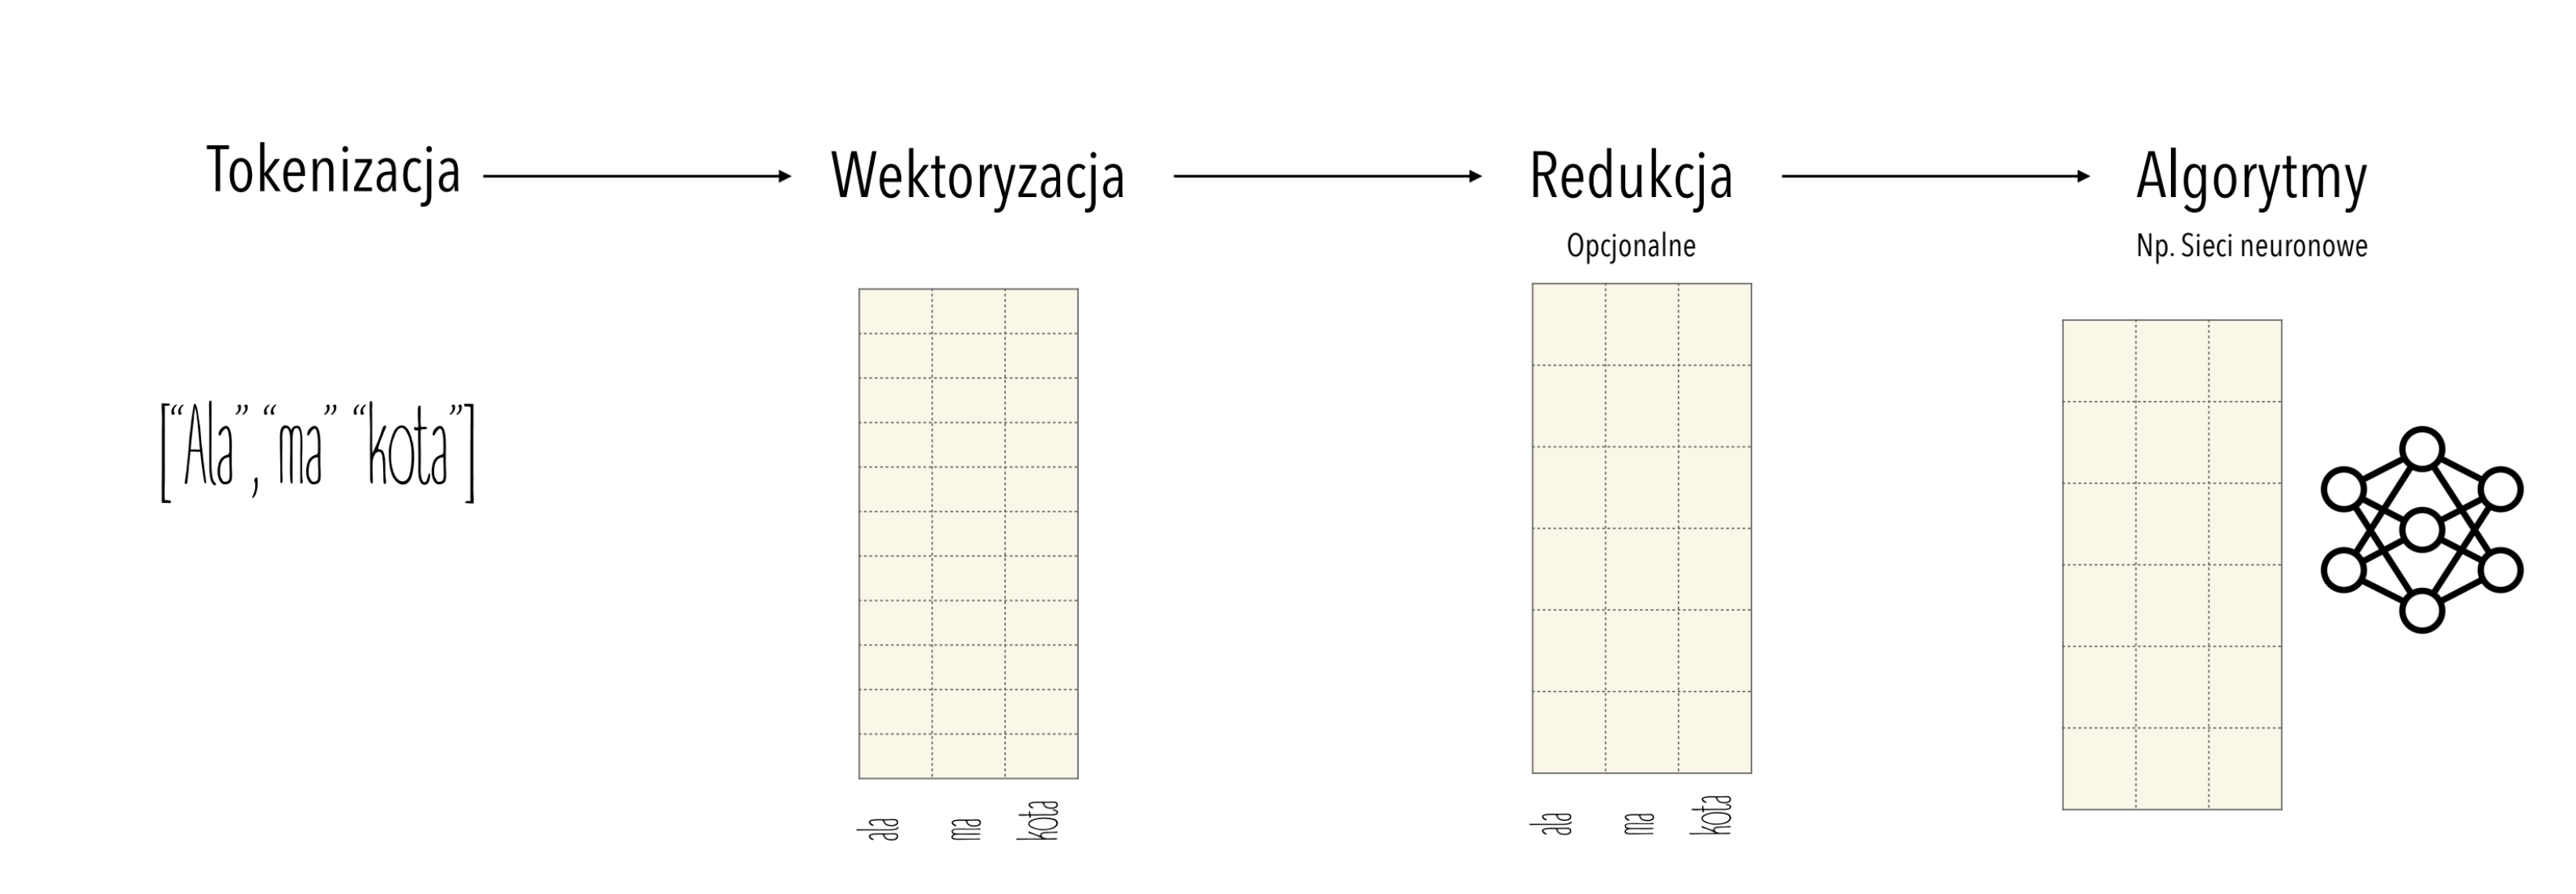

Na dzisiejszych zajęciach zajmujemy się tokenizacją, czyli zamianą tekstu na tokeny.

Token to najmniejsza jednostka tekstu, którą model „rozumie” i przetwarza.

## W jaki sposób tokenizujemy?

Możemy dzielić:

*   na słowa
*   na zdania
*   na morfem
    * Morfem to najmniejsza cząstka języka, która ma jakieś znaczenie.
    * słowo **domki**
      * dom → znaczy „budynek, w którym się mieszka”
      * -ek → oznacza zdrobnienie („mały dom”)
      * -i → końcówka liczby mnogiej
*   na znaki
    * ale czy warto?



### Przykład tokenizacji

In [1]:
!pip install nltk==3.8.1

In [2]:
# NLTK (Natural Language Toolkit) - biblioteka z której skorzystamy
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams

nltk.download('punkt')
tekst = "Domki są piękne. Mam kilka domków w mojej wiosce."

# 1. Tokenizacja na zdania
zdania = sent_tokenize(tekst, language='polish')
print("Tokenizacja na zdania:")
print(zdania)
print()

# 2. Tokenizacja na słowa
slowa = word_tokenize(tekst, language='polish')
print("Tokenizacja na słowa:")
print(slowa)
print()

# 3. Tokenizacja na morfemy (przykład uproszczony)
# Podział słowa "domki" na morfemy: dom-ek-i
# (w praktyce do morfemów używa się bibliotek)
morfemy = {
    "domki": ["dom", "-ek", "-i"],
    "piękne": ["piękn-", "-e"],
    "są": ["być"],
}
print("Przykład tokenizacji na morfemy:")
for slowo, czesci in morfemy.items():
    print(f"{slowo} -> {czesci}")
print()

# 4. Tokenizacja na znaki
znaki = list(tekst)
print("Tokenizacja na znaki:")
print(znaki)
print("Bez powtórzeń:")
print(set(znaki))

Tokenizacja na zdania:
['Domki są piękne.', 'Mam kilka domków w mojej wiosce.']

Tokenizacja na słowa:
['Domki', 'są', 'piękne', '.', 'Mam', 'kilka', 'domków', 'w', 'mojej', 'wiosce', '.']

Przykład tokenizacji na morfemy:
domki -> ['dom', '-ek', '-i']
piękne -> ['piękn-', '-e']
są -> ['być']

Tokenizacja na znaki:
['D', 'o', 'm', 'k', 'i', ' ', 's', 'ą', ' ', 'p', 'i', 'ę', 'k', 'n', 'e', '.', ' ', 'M', 'a', 'm', ' ', 'k', 'i', 'l', 'k', 'a', ' ', 'd', 'o', 'm', 'k', 'ó', 'w', ' ', 'w', ' ', 'm', 'o', 'j', 'e', 'j', ' ', 'w', 'i', 'o', 's', 'c', 'e', '.']
Bez powtórzeń:
{'a', 'k', ' ', 'ę', 'c', 'd', 'M', 'ą', '.', 'w', 'ó', 'l', 'D', 'j', 'p', 'e', 'n', 'i', 'o', 's', 'm'}


[nltk_data] Downloading package punkt to /home/evilree/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Słownik

Słownik to zbiór wszystkich tokenów, które model „zna” i potrafi rozpoznać.

Co jeśli w tekście jest słowo którego nie ma w słowniku modelu?

To problem **Out-Of-Vocabulary**. 🤯

*   Podzielmy słowa na podsłowa które model zna (np WordPiece wykorzystywane przez BERT). To subword tokenization
*   Traktujmy każdy znak jako token
    * Plus: znamy wszystkie litery jakie mogą siepojawić
    * Minus: powoduje to bardzo długie sekwencje tokenów, np litera 'c' nic nie wnosi do sensu zdania
*   Dodajmy nowe słowa w trakcie treningu lub użycia
*   Zastępowanie rzadkich słów tokenem 'UNK' (unknown) – dla nieznanych słów.


Stopword to słowo, które nie niesie dużej treści semantycznej.

Przykład: "i", "na", "że", "the", "is", "of"

ALE!
Znaki interpunkcyjne oraz emotikony mogą nieść znaczenie semantyczne! 😄🤡💩




### Przykład


In [3]:
!pip install transformers

In [4]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tekst = "Serki są smaczne i pachnące 😄"

# Tokenizacja na subwordy
tokens = tokenizer.tokenize(tekst)
print("Subword tokeny:")
print(tokens)

# Pokazanie, które tokeny są OOV (są dzielone na mniejsze części)
for t in tokens:
    if t.startswith("##"):
        print(f"Fragment subword (OOV część): {t}")

/home/evilree/PJN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subword tokeny:
['ser', '##ki', 'sa', 'sm', '##ac', '##z', '##ne', 'i', 'pac', '##hn', '##ace', '[UNK]']
Fragment subword (OOV część): ##ki
Fragment subword (OOV część): ##ac
Fragment subword (OOV część): ##z
Fragment subword (OOV część): ##ne
Fragment subword (OOV część): ##hn
Fragment subword (OOV część): ##ace


## Pre-processing

Podczas pre-processingu możemy:


*   castować do małych liter
*   usuwać specjalne litery (np ą, ü)
*   usuwać znaki specjalne (np ™)




### Przykład

In [5]:
!pip install unidecode

In [6]:
# Przykładowy tekst
tekst = "Domki są piękne™ i wyjątkowe ü!"
print("Oryginalne zdanie: ", tekst)

# 1. Castowanie do małych liter
tekst_lower = tekst.lower()
print("Małe litery:", tekst_lower)

# 2. Usuwanie znaków diakrytycznych (np. ą, ü)
import unidecode
tekst_ascii = unidecode.unidecode(tekst_lower)
print("Bez znaków diakrytycznych:", tekst_ascii)

# 3. Usuwanie znaków specjalnych (np ™, !, ?)
import re
tekst_clean = re.sub(r'[^\w\s]', '', tekst_ascii)
print("Bez znaków specjalnych:", tekst_clean)

Oryginalne zdanie:  Domki są piękne™ i wyjątkowe ü!
Małe litery: domki są piękne™ i wyjątkowe ü!
Bez znaków diakrytycznych: domki sa piekne(tm) i wyjatkowe u!
Bez znaków specjalnych: domki sa pieknetm i wyjatkowe u


# Teraz trochę praktyki...

Instalujemy potrzebną bibliotekę - o samych transformerach będzie więcej później 😼

In [7]:
!pip install transformers

Wybieramy model - każdy model ma swój tokenizer

In [8]:
from transformers import AutoTokenizer

# Wybieramy tokenizer dla wybranego modelu z HF
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

Wybieramy tekst, który chcemy ztokenizować

In [9]:
text = "Kocham ser."

Używamy gotowej metody! 😀


```
.tokenize()
```
podzieli nam tekst na tokeny.



In [10]:
# Podział tekstu na tokeny
tokens = tokenizer.tokenize(text)
print("Tokeny:", tokens)

Tokeny: ['koch', '##am', 'ser', '.']


Chwila, chwila, a co to za "'##am'"? W taki sposób BERT oznaczył sobie kontynuację słowa -> am jest końcówką koch.

Ale chwila, model nadal tego nie zrozumie - musimy zamienić nasze tokeny na reprezentacje cyfrowe

In [11]:
token_ids = tokenizer.convert_tokens_to_ids(tokens)
print("Tokeny w formie ID:", token_ids)

Tokeny w formie ID: [15259, 3286, 14262, 1012]


Przygotujmy od razu cały słownik wejściowy dla modelu - przyda się w przyszłości:

In [12]:
encoded_input = tokenizer(text, return_tensors="pt") # return_tensors="pt" - zamieniamy listy na tensory PyTorch
print("Słownik z inputem dla modelu:")
print(encoded_input)

Słownik z inputem dla modelu:
{'input_ids': tensor([[  101, 15259,  3286, 14262,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}


Na co patrzymy?


```
{
  'input_ids': tensor([[101, 15259, 3286, 14262, 1012, 102]]),
  'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]),
  'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])
}

```


*   'input_ids' - to właśnie nasze tokeny, to ten sam wynik co z poprzedniego kroku: tokenizer.convert_tokens_to_ids(tokens)
    * Dodatkowe tokeny 101 (początek sekwencji) i 102 (koniec sekwencji) to specjalne tokeny modelu BERT - więcej o specjalnych tokenach dowiesz się na wykładzie
*   'token_type_ids'- wskazuje, do której sekwencji należy token (mamy tylko jeden tekst więc same 0)
*   'attention_mask' - Mówi modelowi, które tokeny są „istotne” (1), a które to padding (0).
    * nie dodaliśmy paddingu




## Inne przykłady

### A jak to wygląda z innym modelem?

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

text = "Często jem goudę."
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
encoded_input = tokenizer(text, return_tensors="pt")

print("Tokeny:", tokens)
print("Tokeny w formie ID:", token_ids)
print("Encoded input:", encoded_input)

Tokeny: ['c', '##zes', '##to', 'jem', 'go', '##ude', '.']
Tokeny w formie ID: [1039, 11254, 3406, 24193, 2175, 12672, 1012]
Encoded input: {'input_ids': tensor([[  101,  1039, 11254,  3406, 24193,  2175, 12672,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Na co warto zwrócić uwagę?


*   distilbert używa podobnego tokenizera, więc również mamy '##' w podziale słów
*   Nie ma token_type_ids! distilbert ich nie używa



### Co kiedy mamy kilka tekstów?

In [14]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text1 = "Czy lubisz ser?"
text2 = "Nigdy nie jadłem mozarelli"

encoded_pair = tokenizer(text1, text2, return_tensors="pt")
print("Encoded pair:", encoded_pair)
print("Token_type_ids:", encoded_pair['token_type_ids'])

Encoded pair: {'input_ids': tensor([[  101,  1039,  9096, 11320, 18477,  2480, 14262,  1029,   102,  9152,
          2290,  5149,  9152,  2063, 14855,  2094, 18818,  6633,  9587,  9057,
         13348,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
Token_type_ids: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


Na co warto zwrócić uwagę?


*   Tutaj tokeny pochodzące z pierwszego zdania mają token_type_id = 0, a tokeny z drugiego zdania mają token_type_id = 1



### Padding

In [15]:
sentences = ["Idę kupić brie.", "Mój ulubiony ser to chedar."]

# tokenizer z paddingiem i maksymalną długością batch
encoded_batch = tokenizer(sentences, padding=True, return_tensors="pt")
print("Encoded batch:", encoded_batch)

Encoded batch: {'input_ids': tensor([[  101,  8909,  2063, 13970, 24330,  7987,  2666,  1012,   102,     0,
             0,     0,     0],
        [  101,  9587,  3501, 17359, 12083,  3258,  2100, 14262,  2000, 18178,
          7662,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Na co warto zwróić uwagę?


*   input_ids będą uzupełnione 0 tam, gdzie brak tokenów w krótszym zdaniu.
*   attention_mask pokaże, które tokeny są ważne (1) a które padding (0).



Kiedy używamy paddingu?

Mając wiele zdań w jednym batchu, wszystkie sekwencje muszą mieć ten sam rozmiar


## Części mowy

W przetwarzaniu języka naturalnego (NLP) często chcemy wyłuskać z tekstu określone fragmenty, np. **rzeczowniki**, **czasowniki**, czy **przymiotniki**.  SpaCy umożliwia nam analizę składniową tekstu, a następnie tworzenie **filtrów** w oparciu o **części mowy (POS)** lub **inne cechy tokenów**.

**Podstawowe części mowy w spaCy**

Każdy token w tekście posiada atrybut `.pos_`, który określa jego część mowy. Najważniejsze przykłady:

| POS | Znaczenie | Przykład |
|-----|-----------|----------|
| NOUN | Rzeczownik | "rower", "kot", "samochód" |
| PROPN | Rzeczownik własny (nazwa własna) | "Warszawa", "Apple" |
| VERB | Czasownik | "biega", "sprzedam" |
| ADJ | Przymiotnik | "nowy", "duży" |
| ADV | Przysłówek | "szybko", "bardzo" |
| NUM | Liczba | "1200", "13" |
| PRON | Zaimek | "ja", "ty" |
| DET | Określnik/rodzajnik | "ten", "ta" |

**Tworzenie prostych filtrów w spaCy**

Możemy wykorzystać **Matcher** lub pętlę po tokenach, aby wyłuskać interesujące nas słowa.

In [16]:
!python -m spacy download pl_core_news_sm
import spacy

nlp = spacy.load("pl_core_news_sm")
text = "Bardzo lubię ser pleśniowy."

doc = nlp(text)

nouns = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]
print("Rzeczowniki:", nouns)

  Using cached pl_core_news_sm-3.8.0-py3-none-any.whl (20.2 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
Rzeczowniki: ['ser']


In [17]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

# Wzorzec: przymiotnik + rzeczownik
pattern = [{"POS": "NOUN"}, {"POS": "ADJ"}]
matcher.add("ADJ_NOUN", [pattern])

matches = matcher(doc)
for match_id, start, end in matches:
    span = doc[start:end]
    print("ADJ + NOUN:", span.text)

ADJ + NOUN: ser pleśniowy


Dzięki takim filtrom i częściom mowy możemy łatwo budować ekstraktory informacji z tekstów, np. ogłoszeń, nagłówków czy artykułów.

# Zadania

### Zadanie 1

1.   Porównaj tokeny poniższych zdań wygenerowane przez 3 tokenizery:
     * bert-base-uncased
     * distilbert-base-uncased
     * roberta-base
2.   Sprawdź:
     * Tokeny specjalne używane przez każdy model. Czy występują? Jakie?
     * Czy padding został dodany? Jak wygląda attention_mask?
     * Które modele używają token_type_ids
3.   Uzupełnij tabelkę poniżej na podstawie wyników (jeśli jest problem z uzupełnieniem tabeli proszę słownie zapisać obserwacje)


In [27]:
#zadanie 1
texts = [
    "Kocham ser",
    "W czwartek idę do sklepu.",
    "Czy jutro będzie padać?"
]

# TODO - wyprintuj tokenizację powyższych tekstów
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

for text in texts:
  tokens = tokenizer.tokenize(text)
  print("Tokeny:", tokens)
  encoded_input = tokenizer(text, return_tensors = "pt")
  print(encoded_input)

Tokeny: ['koch', '##am', 'ser']
{'input_ids': tensor([[  101, 15259,  3286, 14262,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}
Tokeny: ['w', 'c', '##z', '##wart', '##ek', 'id', '##e', 'do', 'sk', '##le', '##pu', '.']
{'input_ids': tensor([[  101,  1059,  1039,  2480, 18367,  5937,  8909,  2063,  2079, 15315,
          2571, 14289,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
Tokeny: ['c', '##zy', 'ju', '##tro', 'bed', '##zie', 'pad', '##ac', '?']
{'input_ids': tensor([[  101,  1039,  9096, 18414, 13181,  2793, 14272, 11687,  6305,  1029,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [29]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

for text in texts:
  tokens = tokenizer.tokenize(text)
  print("Tokeny:", tokens)
  encoded_input = tokenizer(text, return_tensors = "pt")
  print(encoded_input)

Tokeny: ['koch', '##am', 'ser']
{'input_ids': tensor([[  101, 15259,  3286, 14262,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}
Tokeny: ['w', 'c', '##z', '##wart', '##ek', 'id', '##e', 'do', 'sk', '##le', '##pu', '.']
{'input_ids': tensor([[  101,  1059,  1039,  2480, 18367,  5937,  8909,  2063,  2079, 15315,
          2571, 14289,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
Tokeny: ['c', '##zy', 'ju', '##tro', 'bed', '##zie', 'pad', '##ac', '?']
{'input_ids': tensor([[  101,  1039,  9096, 18414, 13181,  2793, 14272, 11687,  6305,  1029,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

for text in texts:
  tokens = tokenizer.tokenize(text)
  print("Tokeny:", tokens)
  encoded_input = tokenizer(text, return_tensors = "pt")
  print(encoded_input)

Tokeny: ['K', 'och', 'am', 'Ġser']
{'input_ids': tensor([[   0,  530, 4306,  424, 6821,    2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}
Tokeny: ['W', 'Ġcz', 'wart', 'ek', 'Ġid', 'Ä', 'Ļ', 'Ġdo', 'Ġsk', 'le', 'pu', '.']
{'input_ids': tensor([[    0,   771, 25198, 21660,  1951, 13561,   649,    27,   109,  2972,
           459, 30738,     4,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
Tokeny: ['C', 'zy', 'Ġj', 'ut', 'ro', 'Ġb', 'Ä', 'Ļ', 'd', 'zie', 'Ġp', 'ada', 'Äĩ', '?']
{'input_ids': tensor([[    0,   347,  5144,  1236,  1182,  1001,   741,   649,    27,   417,
         14807,   181,  2095,  4807,   116,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Uzupełnij tabelę swoimi obserwacjami:

| Model        | Tokeny specjalne        | Padding               | Token_type_ids         |
|--------------|------------------------|----------------------|----------------------|
| Przykład         | [nazwa tokenu] / NIE jeśli nie występują          | Tak, jak zaznaczają? / Nie              | Tak / Nie                   |
| BERT         | 101,102         |    NIE       |      TAK      |
| DistilBERT   | 101,102         |   NIE        |      NIE      |
| RoBERTa      | 0,2         |     NIE      |       NIE
     |



## Zadanie 2

Teraz zrobimy zadanie z spaCy i jego Matcherem, który pozwala wyszukiwać wzorce w tekście na podstawie części mowy (POS tagging).



In [21]:
!pip install spacy
!python -m spacy download pl_core_news_sm

import spacy
from spacy.matcher import Matcher

nlp = spacy.load("pl_core_news_sm")

  Using cached pl_core_news_sm-3.8.0-py3-none-any.whl (20.2 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')


In [22]:
ads = [
    "Sprzedam rower górski za 1200 zł",
    "Do kupienia laptop Dell 3500 PLN",
    "Oferuję kanapę w dobrym stanie, cena 800 zł",
    "Sprzedam smartfon iPhone 13 za 4000 zł",
    "Na sprzedaż samochód Toyota Corolla, cena 15000 zł"
]

In [23]:
# TODO - przygotuj filtry
pattern_price = [{"IS_DIGIT": True}, {"LOWER": {"IN": ["zł", "pln"]}}]
matcher = Matcher(nlp.vocab)
matcher.add("price", [pattern_price])

for ad in ads:
    doc = nlp(ad)
    matches = matcher(doc)
    print(f"\n📌 Ogłoszenie: {ad}")

    item = None

    for token in doc:
        if token.pos_ == "VERB": #szukamy po czesci mowy
            for child in token.children:
                if child.dep_ in ("obj", "obl") and child.pos_ == "NOUN": #szukamy rzeczownika ktory jest dopelnieniem lub okolicznikiem
                    item = child.lemma_ #lemma_ zwraca forme podstawowa
                    break
        if item:
            break

    if not item:
        for i, token in enumerate(doc):
            if token.text.lower() in ("sprzedaż", "kupienia"):
                for right in doc[i + 1 : i + 4]: #patrzymy na trzy nastepne tokeny po sprzedaz albo kupienia
                    if right.pos_ == "NOUN":
                        item = right.lemma_
                        break
            if item:
                break

    if item:
        print(f"Przedmiot: {item}")

    for match_id, start, end in matches:
        span = doc[start:end]
        if nlp.vocab.strings[match_id] == "price":
            print(f"Cena: {span.text}")



📌 Ogłoszenie: Sprzedam rower górski za 1200 zł
Przedmiot: rower
Cena: 1200 zł

📌 Ogłoszenie: Do kupienia laptop Dell 3500 PLN
Przedmiot: laptop
Cena: 3500 PLN

📌 Ogłoszenie: Oferuję kanapę w dobrym stanie, cena 800 zł
Przedmiot: kanapa
Cena: 800 zł

📌 Ogłoszenie: Sprzedam smartfon iPhone 13 za 4000 zł
Przedmiot: smartfon
Cena: 4000 zł

📌 Ogłoszenie: Na sprzedaż samochód Toyota Corolla, cena 15000 zł
Przedmiot: samochód
Cena: 15000 zł
